# Конструирование алгоритмов mclp

In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
from genesis.core import BestPointsBase, MetricBase, StateBase
from genesis.best_points import BestNodeHillClimbing
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime
from genesis.tools import timing
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import osmnx as ox

In [2]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

{'dynamic_nodes': {1296599762: 'A', 2042076750: 'B', 2760591335: 'c', 4901942432: 'd'}}


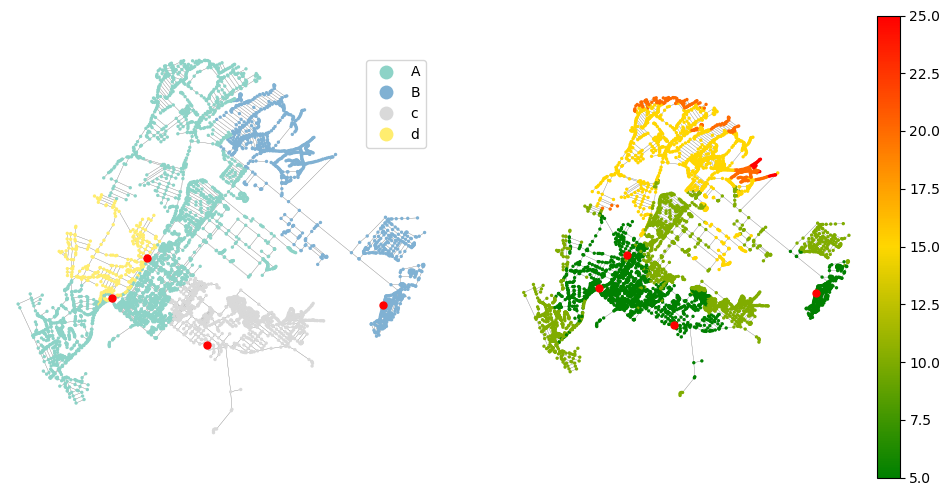

{'best_metric': 7.262001771503841, 'dynamic_nodes': {1296599762: 'A', 2042076750: 'B', 2760591335: 'c', 4901942432: 'd'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 5.565531451061565, 'dynamic_nodes': {426923835: 'A', 2034401575: 'B', 2054468329: 'c', 5116722296: 'd'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 5.328266798562084, 'dynamic_nodes': {426923835: 'A', 2034401724: 'B', 2054468329: 'c', 5116722295: 'd'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 5.306303782080565, 'dynamic_nodes': {426923872: 'A', 2034401724: 'B', 2054468329: 'c', 5116722295: 'd'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 5.212369590362853, 'dynamic_nodes': {1297080757: 'A', 2034401724: 'B', 2054468329: 'c', 2712076292: 'd'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 5.20859914886576, 'dynamic_nodes': {1296599777: 'A', 2034401723: 'B', 2054468329: 'c', 2712076292: 'd'}, 'static_nodes': {}}
ВРЕМЯ: 17.59 сек
{'dynamic_nodes': {1296599777: 'A', 2034401723: 'B', 2054468329: 'c', 2712076292: 'd'}}


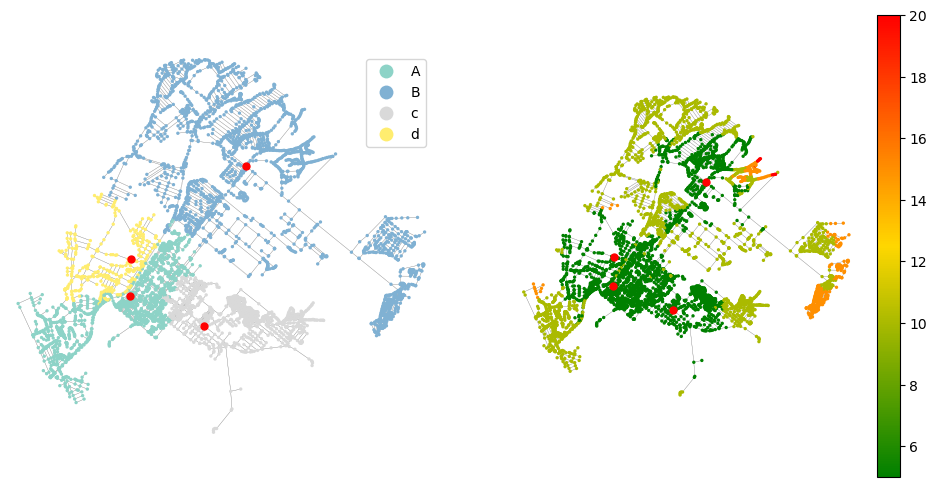

In [49]:
class BestNodesGenesis(BestPointsBase):
    '''
    Поиск лучших узлов для размещения n объектов.
    '''

    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 best_point_function: BestPointsBase,
                 appr_val: float = 0.95,
                 iterations=5,
                 **kwargs) -> None:
        
        self.best_point_function = best_point_function
        self.appr_val = appr_val
        self.iterations = iterations
        super().__init__(state_function, metric_function, **kwargs)


    def __call__(self,
                 env:nx.MultiDiGraph,
                 dynamic_nodes: list|dict,
                 static_nodes: list|dict = None,
                 before_iters_start_function=None,
                 iter_calc_end_function=None,
                 area = None,
                 **kwargs):
        
        # Проверка корректности пришедших данных
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип аргумента `env` должен быть MultiDiGraph!")
        if not static_nodes is None:
            if not ((isinstance(dynamic_nodes,list) and isinstance(static_nodes,list)) or \
                (isinstance(dynamic_nodes,dict) and isinstance(static_nodes,dict))):
                raise TypeError("Аргументы `dynamic_nodes` и `static_nodes` должны быть одинакового типа: list|dict")

        # Если статические узлы не указаны - заменяем значение переменной с None
        # на [] или {} в зависимости от типа данных `dynamic_nodes`
        if static_nodes is None:
            if isinstance(dynamic_nodes,list):
                static_nodes = []
            elif isinstance(dynamic_nodes,dict):
                static_nodes = {}

        # 0. Получение суммарного списка (или словаря) узлов для расчета состояния и метрик
        if isinstance(dynamic_nodes,list):
            start_nodes = dynamic_nodes+static_nodes
        elif isinstance(dynamic_nodes,dict):
            start_nodes = {**dynamic_nodes, **static_nodes}

        # 1. Расчет состояния
        times, nearest = self.state_function(env=env, points=start_nodes, **kwargs)   # area=area, - убрал

        # 2. Расчет стартовой метрики состояния и определение стартового размещения
        best_metric = self.metric_function(times, area=area, **kwargs)
        best_dynamic_nodes = dynamic_nodes

        # выполняем функцию перед началом итераций
        if before_iters_start_function:
            before_iters_start_function(
                                    best_metric=best_metric,
                                    dynamic_nodes=dynamic_nodes,
                                    static_nodes=static_nodes
                                    )

        # Итерации расчета лучшего размещения
        for iteration in range(self.iterations):

            # 2. Поиск для каждого из dinamic_nodes наилучшего размещения в пределах своей зоны обслуживания
            # 2.1. Для списка:
            if isinstance(dynamic_nodes, list):
                new_dynamic_nodes = []
                for dynamic_node in dynamic_nodes:

                    # Определяем список узлов в которые из узла dynamic_node можно прибыть первым
                    node_area_nodes = [n for n,v in nearest.items() if v==dynamic_node]

                    # Определяем подграф зоны обслуживания для узла dynamic_node
                    node_area_G = nx.subgraph(env, node_area_nodes)
                    # print(dynamic_node in node_area_nodes)

                    # Определяем лучший узел
                    best_nodes, _ = self.best_point_function(env=node_area_G, 
                                                                    start_node=dynamic_node,
                                                                    area=area,
                                                                    appr_val = self.appr_val,
                                                                    **kwargs)[:2] # [:2] Это для ограничения вывода дебаг-данных в некоторых функциях
                    if isinstance(best_nodes, list):
                        best_nodes = best_nodes[0]
                    # Добавляем полученный узел в новый список
                    new_dynamic_nodes.append(best_nodes)
            else:
                new_dynamic_nodes = {}
                for dynamic_node_id, dynamic_node_key in dynamic_nodes.items():

                    # Определяем список узлов в которые из узла dynamic_node можно прибыть первым
                    node_area_nodes = [k for k,v in nearest.items() if v==dynamic_node_key]

                    # Определяем подграф зоны обслуживания для узла dynamic_node
                    node_area_G = nx.subgraph(env, node_area_nodes)

                    # Определяем лучший узел
                    best_nodes, _ = self.best_point_function(env=node_area_G, 
                                                                    start_node=dynamic_node_id,
                                                                    area=area,
                                                                    appr_val = self.appr_val,
                                                                    **kwargs)[:2] # [:2] Это для ограничения вывода дебаг-данных в некоторых функциях
                    if isinstance(best_nodes, list):
                        best_nodes = best_nodes[0]
                    # Добавляем полученный узел в новый список
                    new_dynamic_nodes[best_nodes] = dynamic_node_key

            # Заменяем список dynamic_nodes списком с новыми, лучшими узлами
            dynamic_nodes = new_dynamic_nodes

            # Приведение к типу переменной в соответствии с типом `dynamic_nodes`
            if isinstance(dynamic_nodes,list):
                start_nodes = dynamic_nodes+static_nodes
            elif isinstance(dynamic_nodes,dict):
                start_nodes = {**dynamic_nodes, **static_nodes}

            # Расчет состояния
            times, nearest = self.state_function(env=env, points=start_nodes, **kwargs)   # area=area, 

            # Расчет метрики состояния
            state_metric = self.metric_function(times, area=area, **kwargs)
            # if best_metric is None:
            #     best_metric = state_metric

            # Оценка метрики состояния
            if self.metric_function.compare(best_metric, state_metric) == state_metric:
                best_metric = state_metric
                best_dynamic_nodes = dynamic_nodes

            # Выполняем функцию завершения расчета для итерации
            if iter_calc_end_function:
                iter_calc_end_function(i=iteration,
                                       best_metric=best_metric,
                                       dynamic_nodes=best_dynamic_nodes,
                                       static_nodes=static_nodes)

        return best_dynamic_nodes, best_metric


cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])

def iter_state_func(**kwds):
    # print('Итерация:', kwds['i'])
    print(kwds)
    dynamic_nodes = kwds['dynamic_nodes']
    if isinstance(dynamic_nodes, dict):
        dynamic_nodes_id = list(dynamic_nodes.keys())
    else:
        dynamic_nodes_id = dynamic_nodes

    try:
        static_nodes = kwds['static_nodes']
        if isinstance(static_nodes, dict):
            static_nodes_id = list(static_nodes.keys())
        else:
            static_nodes_id = static_nodes
    except:
        static_nodes = None
        
    if not static_nodes is None:
        if isinstance(dynamic_nodes,list):
            start_nodes = dynamic_nodes+static_nodes
        elif isinstance(dynamic_nodes,dict):
            start_nodes = {**dynamic_nodes, **static_nodes}
    else:
        start_nodes = dynamic_nodes
    times, nearest = FirstArrivalUnitState()(env=G, points=start_nodes)
    times = {k:(1+int(t//5))*5 for k, t in times.items()}

    nx.set_node_attributes(G, pd.Series(nearest, dtype=str), 'nearest')
    nx.set_node_attributes(G, times, 'route_time')

    nds = ox.graph_to_gdfs(G, edges=False)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
    nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3', legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax1, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax1, markersize=25, color='k')

    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
    nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1, legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax2, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax2, markersize=25, color='k')

    plt.show()





# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)


nodes = list(G.nodes())
# existed_units = {nodes[100]:'A', 
#                 nodes[2000]:'B', 
#                 }
# new_units = {nodes[3000]:'c',
#              nodes[4000]:'d'}
new_units = {nodes[100]:'A', 
            nodes[2000]:'B',
            nodes[3000]:'c',
            nodes[4000]:'d'}
# existed_units = list(existed_units.keys())
# new_units = list(new_units.keys())
# print(existed_units)

# iter_end_func(dynamic_nodes=new_units, static_nodes={})


BNF = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime())
# def BNF(env, start_node, area=None, appr_val: float = 0.95):
#     bnch_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max), appr_val=appr_val)
#     bnch_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(), appr_val=appr_val)

#     best_node, best_metric = bnch_max(env=env, start_node=start_node, area=area)
#     best_node, best_metric = bnch_mean(env=env, start_node=best_node, area=area)
#     return best_node, best_metric

BNG = timing(BestNodesGenesis(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF,
                    #    best_point_function=BestNodeHillClimbingMaxMean,
                       appr_val=1,  # 0.95
                       iterations=5,
                       ))

# BNG(env=G, dynamic_nodes=new_units, static_nodes=existed_units, iter_calc_end_function=iter_end_func, area=points_mask)
# BNG(env=G, dynamic_nodes=new_units, static_nodes=existed_units, iter_calc_end_function=iter_end_func)
# BNG(env=G, dynamic_nodes=new_units, iter_calc_end_function=iter_end_func, area=points_mask)

iter_state_func(dynamic_nodes=new_units)
optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    # static_nodes=existed_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    # area=points_mask,
    )
iter_state_func(dynamic_nodes=optimal_nodes)

# Тест-примеры использования

In [ ]:
from genesis.mclp import BestNodesGenesis

Расчет размещения 2 подразделений. 

Метрика: **среднее время**

In [12]:
def iter_func(**kwds):
    'Функция вывода хода расчета'
    print(kwds)

{'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}}


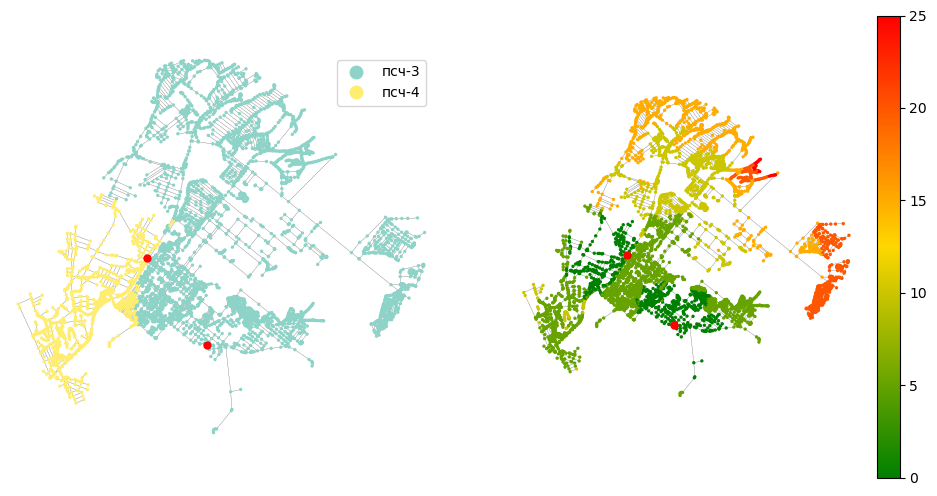

{'best_metric': 10.395688408521078, 'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 7.454992334016819, 'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 7.454992334016819, 'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 7.454992334016819, 'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 7.454992334016819, 'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 7.454992334016819, 'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}, 'static_nodes': {}}
ВРЕМЯ: 24.79 сек
{426923808: 'псч-3', 5116722295: 'псч-4'} 7.454992334016819
{'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}}


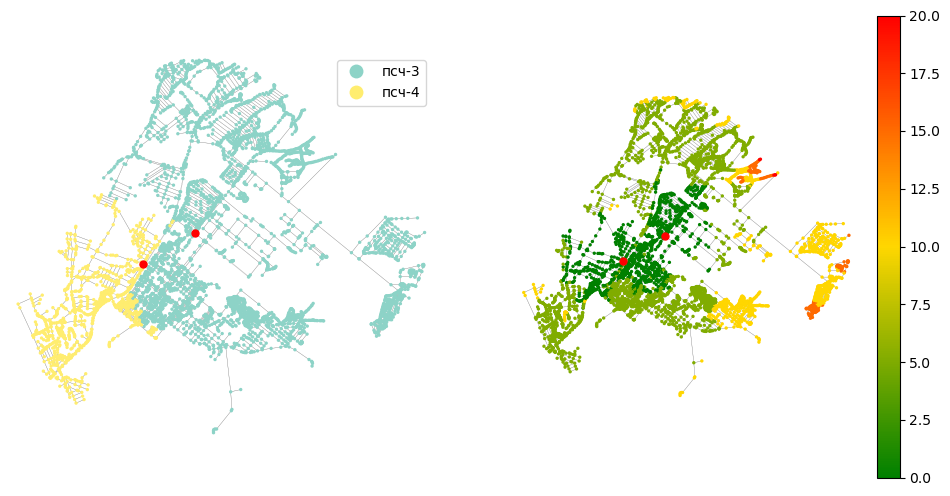

In [23]:
# Перечень узлов
nodes = list(G.nodes())

# Перечень стартовых узлов размещения подразделений
new_units = {
            nodes[3000]:'псч-3',
            nodes[4000]:'псч-4',
            }
# Печать стартового состояния
iter_state_func(dynamic_nodes=new_units)

# Функция расчета лучшего узла. Установка стартовых опций
BNF = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime())
# Функция расчета лучших размещений. Установка стартовых опций
BNG = timing(BestNodesGenesis(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF,
                       appr_val=0.95,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes)

Расчет размещения 2 подразделений. 

Метрика: **максимальное время**

{'best_metric': 27.880806571428575, 'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 17.076365714285714, 'dynamic_nodes': {2034401663: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 16.58431628571429, 'dynamic_nodes': {426923809: 'псч-3', 1296599777: 'псч-4'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 16.58431628571429, 'dynamic_nodes': {426923809: 'псч-3', 5574240347: 'псч-4'}, 'static_nodes': {}}
ВРЕМЯ: 37.14 сек
{'dynamic_nodes': {426923809: 'псч-3', 5574240347: 'псч-4'}}


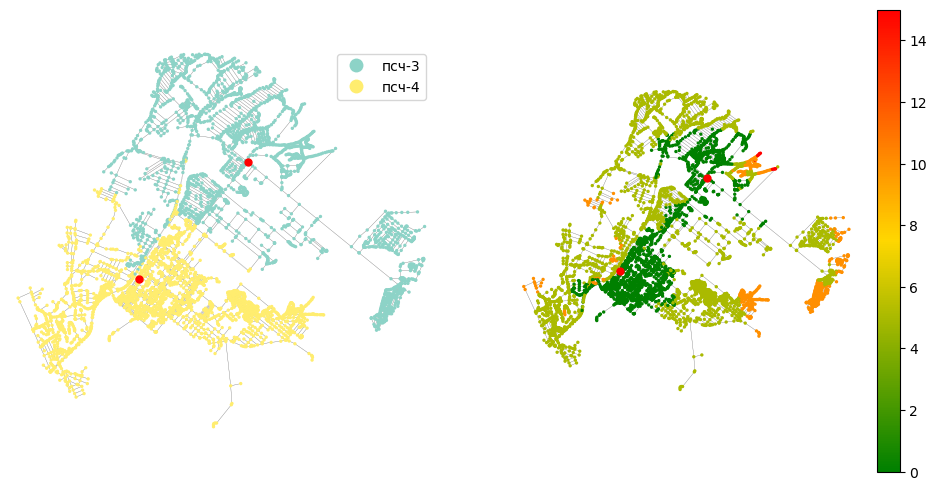

In [24]:
# Функция расчета лучшего узла. Установка стартовых опций
BNF = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(f=np.max))
# Функция расчета лучших размещений. Установка стартовых опций
BNG = timing(BestNodesGenesis(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(f=np.max),
                       best_point_function=BNF,
                       appr_val=0.95,
                       iterations=3,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes)

Расчет размещения 2 подразделений. 

Метрика: **максимальное время + среднее время**

{'best_metric': 10.395688408521078, 'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
ВРЕМЯ: 57.03 сек
{'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}}


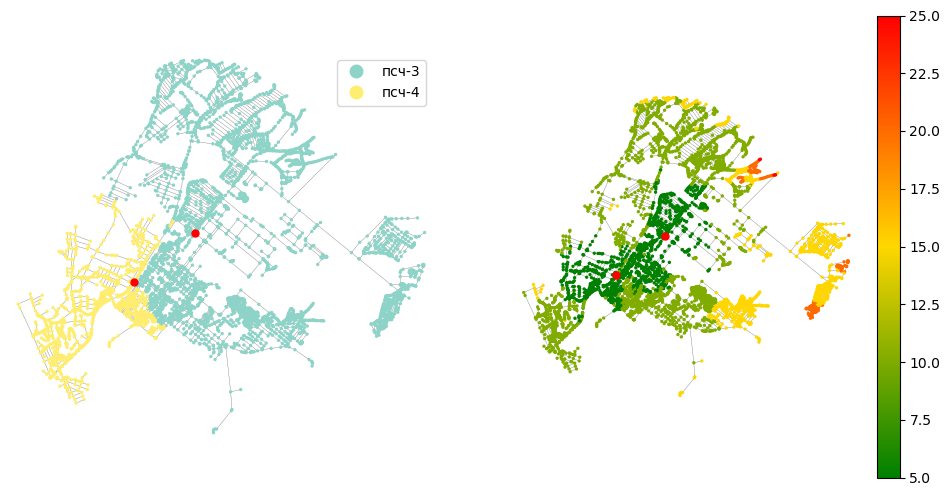

In [28]:
# Функция расчета лучшего узла. Установка стартовых опций
def BNF(env, start_node, area=None, appr_val: float = 0.95):
    bnch_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max), appr_val=appr_val)
    bnch_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(), appr_val=appr_val)

    best_node, best_metric = bnch_max(env=env, start_node=start_node, area=area)
    best_node, best_metric = bnch_mean(env=env, start_node=best_node, area=area)
    return best_node, best_metric
# Функция расчета лучших размещений. Установка стартовых опций
BNG = timing(BestNodesGenesis(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF,
                       appr_val=0.95,
                       iterations=3,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes)

Расчет размещения 2 новых подразделений при наличии 1 существующего.

Метрика: **максимальное время + среднее время**

{'dynamic_nodes': {4116059950: 'новое 1', 2712076292: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}


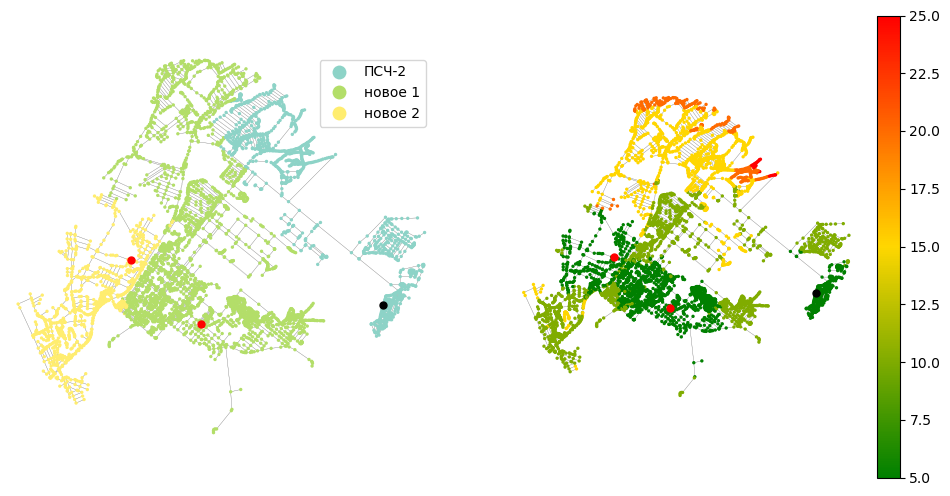

{'best_metric': 8.404563806413517, 'dynamic_nodes': {2760591335: 'новое 1', 4901942432: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 0, 'best_metric': 6.536903003984115, 'dynamic_nodes': {426923837: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 1, 'best_metric': 6.40652318712365, 'dynamic_nodes': {426923808: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 2, 'best_metric': 6.40652318712365, 'dynamic_nodes': {426923808: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 3, 'best_metric': 6.40652318712365, 'dynamic_nodes': {426923808: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 4, 'best_metric': 6.40652318712365, 'dynamic_nodes': {426923808: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
ВРЕМЯ: 59.44 сек
{'dynamic_nodes': {426923808: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}


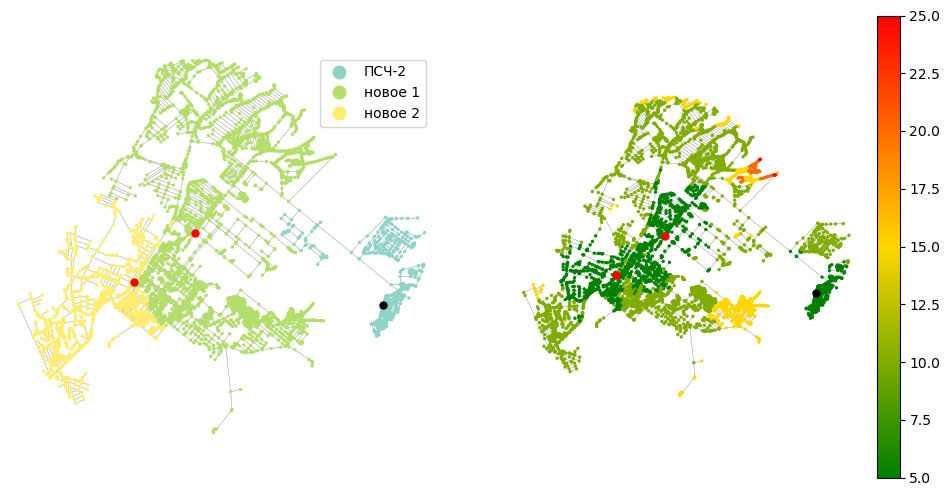

In [30]:
# Словари подразделений
existed_units = {
    nodes[2000]:'ПСЧ-2',
    }
new_units = {
    nodes[3000]:'новое 1',
    nodes[4000]:'новое 2'
    }

# Печать карты стартового размещения
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)

# Функция расчета лучшего узла. Установка стартовых опций
def BNF(env, start_node, area=None, appr_val: float = 0.95):
    bnch_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max), appr_val=appr_val)
    bnch_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(), appr_val=appr_val)

    best_node, best_metric = bnch_max(env=env, start_node=start_node, area=area)
    best_node, best_metric = bnch_mean(env=env, start_node=best_node, area=area)
    return best_node, best_metric
# Функция расчета лучших размещений. Установка стартовых опций
BNG = timing(BestNodesGenesis(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF,
                       appr_val=0.95,
                       iterations=5,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG(env=G,
    static_nodes=existed_units,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)

Расчет размещения 2 новых подразделений при наличии 1 существующего.

Метрика: **максимальное время + среднее время**

Учитывается зона в пределах `area`.

{'best_metric': 6.947033447570087, 'dynamic_nodes': {2760591335: 'новое 1', 4901942432: 'новое 2'}, 'static_nodes': {}}
ВРЕМЯ: 20.0 сек
{'best_metric': 4.350491521585032, 'dynamic_nodes': {4116030638: 'новое 1', 3114758150: 'новое 2'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 3.678390398205505, 'dynamic_nodes': {1297036351: 'новое 1', 5574240399: 'новое 2'}, 'static_nodes': {}}
ВРЕМЯ: 7.53 сек
{'dynamic_nodes': {1297036351: 'новое 1', 5574240399: 'новое 2'}}


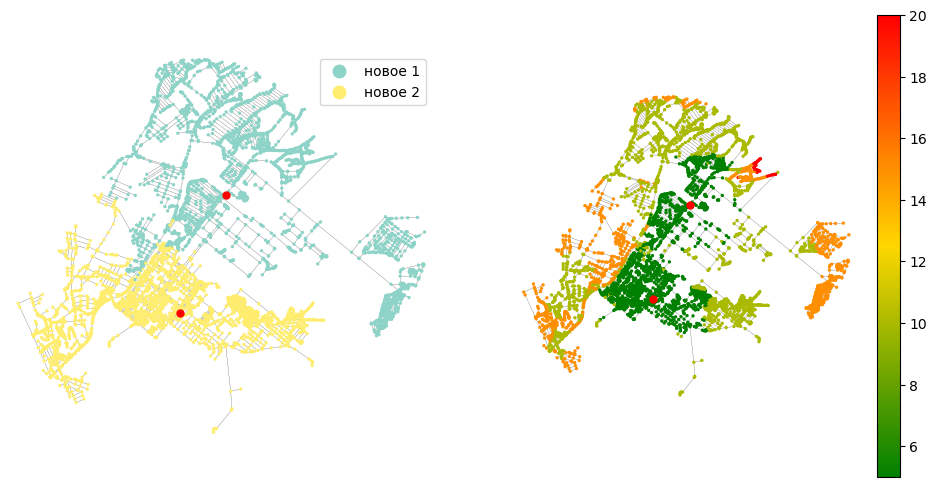

In [72]:
# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)

# Узлы графа УДС
nodes = list(G.nodes())

# Словари подразделений
# Существующие
existed_units = {
    # nodes[2000]:'ПСЧ-2',
    }
# Новые
new_units = {
    nodes[3000]:'новое 1',
    nodes[4000]:'новое 2'
    }

# Функция расчета лучшего узла. Установка стартовых опций
# def BNF(env, start_node, area=None, appr_val: float = 0.95):
#     bnch_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max), appr_val=appr_val)
#     bnch_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(), appr_val=appr_val)

#     best_node, best_metric = bnch_max(env=env, start_node=start_node, area=area)
#     best_node, best_metric = bnch_mean(env=env, start_node=best_node, area=area)
#     return best_node, best_metric
BNF_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max), appr_val=0)
BNF_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max), appr_val=0)
# Функция расчета лучших размещений. Установка стартовых опций
BNG_max = timing(BestNodesGenesis(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF_max,
                       appr_val=0,  #0.95
                       iterations=1,
                       ))
BNG_mean = timing(BestNodesGenesis(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF_mean,
                       appr_val=0,  #0.95
                       iterations=1,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG_max(env=G,
    # static_nodes=existed_units,
    dynamic_nodes=new_units,
    area=points_mask,
    before_iters_start_function=iter_func,
    # iter_calc_end_function=iter_func,
    )
optimal_nodes, best_metric = BNG_mean(env=G,
    # static_nodes=existed_units,
    dynamic_nodes=optimal_nodes,
    area=points_mask,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes)

<Axes: >

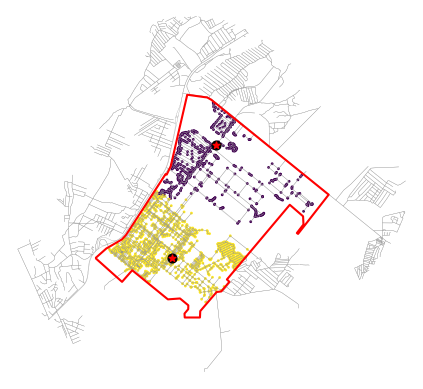

In [73]:
ns = ox.graph_to_gdfs(G, edges=False)
points_mask = ns.within(area.iloc[0].geometry)

times, nearest = FirstArrivalUnitState()(env=G, points=list(optimal_nodes.keys()), area=points_mask)

ns['nearest'] = nearest


ax = ns[ns['nearest'].notna()].plot(markersize=1, column='nearest')
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax)
area.boundary.plot(ax=ax, color='r')
ns.loc[optimal_nodes.keys()].plot(ax=ax, markersize=40, color='k')
ns.loc[optimal_nodes.keys()].plot(ax=ax, markersize=25, color='red', marker="*")

In [41]:
ns.to_file(r'tests\data\t.gpkg')

In [47]:
units = ns.loc[optimal_nodes.keys()].copy()
units['unit'] = optimal_nodes
units.to_file(r'tests\data\unit_t.gpkg')

## Проблема

Подразделение "новое 2" не заходит внутрь зоны area, хотя по логике должно. Скорее всего вычисляется метрика для всего подграфа.

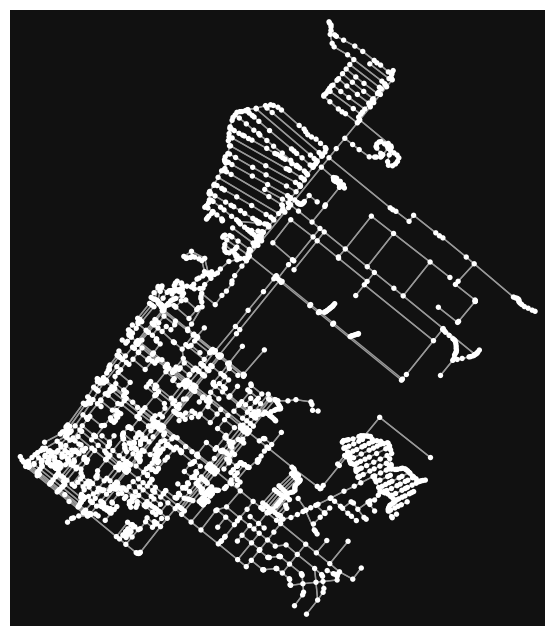

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [61]:
GG = ox.truncate.truncate_graph_polygon(G, area.geometry.iloc[0])
ox.plot_graph(GG)

Здесь локальные оптимумы...

{'best_metric': 4.111567542169069, 'dynamic_nodes': {1545616091: 'a', 1552046387: 'b'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 3.697298005799476, 'dynamic_nodes': {426923846: 'a', 1555142677: 'b'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 3.533418940399738, 'dynamic_nodes': {426923846: 'a', 426923792: 'b'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 3.2956131199541283, 'dynamic_nodes': {426923855: 'a', 2034401362: 'b'}, 'static_nodes': {}}
ВРЕМЯ: 14.23 сек
{'dynamic_nodes': {426923855: 'a', 2034401362: 'b'}, 'static_nodes': {}}


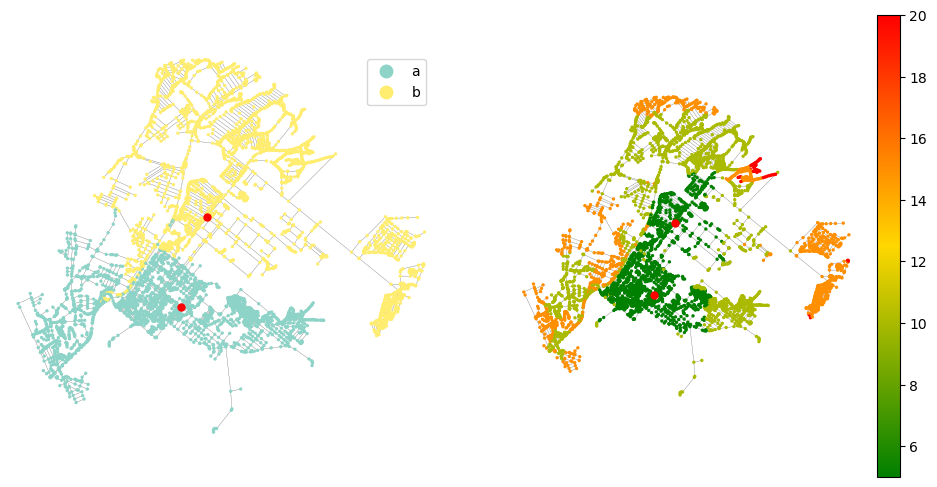

In [66]:
nds = list(GG.nodes())
test_nodes = {
    nds[100]:'a',
    nds[200]:'b',
}

# Расчет лучших мест
optimal_nodes, best_metric = BNG(env=GG,
    # static_nodes=existed_units,
    dynamic_nodes=test_nodes,
    # area=points_mask,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)